# Factor Zoo Validation via Double-Selection LASSO

**Chapter 15: Causal Estimation**
**Docker image**: `ml4t`

This notebook applies the double-selection LASSO framework from Feng, Giglio,
and Xiu (2020) to test whether candidate factors have genuine marginal pricing
power after controlling for existing factors. This connects the causal inference
machinery of this chapter to the latent factor models of Chapter 14.

## The Problem

A factor that appears significant against a simple benchmark (e.g., CAPM) may
lose significance when tested against the full factor zoo. Naive sequential
testing suffers from omitted variable bias — the candidate may proxy for an
existing factor that was excluded from the benchmark.

## The Solution: Post-Double-Selection (BCH 2014)

The Belloni-Chernozhukov-Hansen (2014) procedure, adapted by Feng-Giglio-Xiu
for asset pricing, is a special case of the DML framework from §15.3:

1. **Pricing LASSO**: Select which existing factors best explain asset returns
2. **Correlation LASSO**: Select which existing factors correlate most with
   the candidate — these would cause omitted variable bias if excluded
3. **OLS on union**: Test the candidate's coefficient on the union of both
   selected sets, providing robust inference

## Learning Objectives

- Understand why naive factor testing produces false positives
- Implement post-double-selection for factor validation using sklearn
- Apply the framework to real ETF factor returns from Chapter 14
- Connect the BCH procedure to the DML framework of §15.3

**Data**: ETF daily returns (same 100-ETF universe as Ch14 NB01/NB05).

**Book Reference**: Chapter 14, §14.5 (Taming the Factor Zoo);
Chapter 15, §15.3 (Double Machine Learning)

**Prerequisites**: [`01_pca_equity_sectors`](../14_latent_factors/01_pca_equity_sectors.ipynb),
[`03_econml_dml`](03_econml_dml.ipynb)

## Setup

In [1]:
"""Factor Zoo Validation — Post-Double-Selection LASSO for marginal factor testing."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.linear_model import LassoCV, LinearRegression

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
MIN_OBSERVATIONS = 252
N_PCA_FACTORS = 10
SIGNIFICANCE_LEVEL = 0.05
MAX_SYMBOLS = 0  # 0 = all
HOLDOUT_SYMBOL = "SPY"  # broad-market ETF held out as the pricing outcome
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Build Factor Returns from ETF Data

We hold out a single broad-market ETF (`SPY` by default) as the *pricing
outcome* and build the factor zoo from the remaining ETFs. Holding out the
outcome is essential: if we used an equal-weight mean of the same ETFs that
define the PCA factors, the outcome would lie in the column span of the
controls and the post-double-selection regression would be tautological
(R² ≈ 1, t-stats spuriously inflated). Pricing a held-out asset with a
zoo built from disjoint ones is the FGX (2020) workflow.

In [4]:
etf_data = load_etfs(start_date=START_DATE, end_date=END_DATE)

# Daily returns
etf_returns = (
    etf_data.sort("timestamp")
    .with_columns(pl.col("close").pct_change().over("symbol").alias("return"))
    .drop_nulls(subset=["return"])
)

# Filter to symbols with sufficient history
symbol_counts = etf_returns.group_by("symbol").len()
valid_symbols = symbol_counts.filter(pl.col("len") >= MIN_OBSERVATIONS)["symbol"].to_list()
if HOLDOUT_SYMBOL not in valid_symbols:
    raise ValueError(f"Holdout {HOLDOUT_SYMBOL!r} missing from ETF universe")
if MAX_SYMBOLS > 0:
    valid_symbols = valid_symbols[:MAX_SYMBOLS]
    if HOLDOUT_SYMBOL not in valid_symbols:
        valid_symbols = valid_symbols + [HOLDOUT_SYMBOL]
etf_returns = etf_returns.filter(pl.col("symbol").is_in(valid_symbols))

# Pivot to wide-format return matrix
return_wide = etf_returns.pivot(on="symbol", index="timestamp", values="return").sort("timestamp")
symbols_all = [c for c in return_wide.columns if c != "timestamp"]
returns_all = return_wide.select(symbols_all).to_numpy().astype(np.float64)
returns_all = np.nan_to_num(returns_all, nan=0.0)

# Split: held-out outcome vs. zoo universe.
holdout_idx = symbols_all.index(HOLDOUT_SYMBOL)
holdout_return = returns_all[:, holdout_idx]
zoo_mask = np.ones(returns_all.shape[1], dtype=bool)
zoo_mask[holdout_idx] = False
returns_np = returns_all[:, zoo_mask]
symbols = [s for s in symbols_all if s != HOLDOUT_SYMBOL]
T, N = returns_np.shape

print(f"Outcome: {HOLDOUT_SYMBOL} returns ({T} days)")
print(f"Zoo universe: {N} ETFs (SPY held out)")

Outcome: SPY returns (4780 days)
Zoo universe: 99 ETFs (SPY held out)


In [5]:
# PCA factor returns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_np)
pca = PCA(n_components=N_PCA_FACTORS)
pca.fit(returns_scaled)
factor_returns = returns_scaled @ pca.components_.T  # T × K

factor_names = [f"PC{i + 1}" for i in range(N_PCA_FACTORS)]
var_explained = pca.explained_variance_ratio_

print(f"PCA factors: {N_PCA_FACTORS} components, cumulative variance: {var_explained.sum():.1%}")
for i in range(min(5, N_PCA_FACTORS)):
    sr = factor_returns[:, i].mean() / factor_returns[:, i].std() * np.sqrt(252)
    print(f"  {factor_names[i]}: var={var_explained[i]:.1%}, Sharpe={sr:+.2f}")

PCA factors: 10 components, cumulative variance: 79.2%
  PC1: var=50.4%, Sharpe=+0.00
  PC2: var=8.2%, Sharpe=+0.00
  PC3: var=5.7%, Sharpe=-0.00
  PC4: var=3.9%, Sharpe=+0.00
  PC5: var=2.7%, Sharpe=-0.00


## 2. Construct Candidate Factors

Beyond PCA, we build characteristic-sorted managed portfolios as candidate
factors. These mimic the practitioner's situation: "I have a new signal —
is it redundant given the existing factor structure?"

In [6]:
# Managed-portfolio factor construction from ETF characteristics
# 20-day momentum: long top quintile, short bottom quintile
momentum_20d = np.zeros(T)
for t in range(20, T):
    mom = returns_np[t - 20 : t].sum(axis=0)
    top = mom >= np.percentile(mom, 80)
    bot = mom <= np.percentile(mom, 20)
    if top.sum() > 0 and bot.sum() > 0:
        momentum_20d[t] = returns_np[t, top].mean() - returns_np[t, bot].mean()

# 60-day momentum
momentum_60d = np.zeros(T)
for t in range(60, T):
    mom = returns_np[t - 60 : t].sum(axis=0)
    top = mom >= np.percentile(mom, 80)
    bot = mom <= np.percentile(mom, 20)
    if top.sum() > 0 and bot.sum() > 0:
        momentum_60d[t] = returns_np[t, top].mean() - returns_np[t, bot].mean()

In [7]:
# Low-volatility factor: long low-vol quintile, short high-vol quintile
low_vol = np.zeros(T)
for t in range(60, T):
    vol = returns_np[t - 60 : t].std(axis=0)
    low = vol <= np.percentile(vol, 20)
    high = vol >= np.percentile(vol, 80)
    if low.sum() > 0 and high.sum() > 0:
        low_vol[t] = returns_np[t, low].mean() - returns_np[t, high].mean()

# Mean-reversion factor: short recent winners, long recent losers (contrarian)
mean_rev = np.zeros(T)
for t in range(5, T):
    ret5 = returns_np[t - 5 : t].sum(axis=0)
    top = ret5 >= np.percentile(ret5, 80)
    bot = ret5 <= np.percentile(ret5, 20)
    if top.sum() > 0 and bot.sum() > 0:
        mean_rev[t] = returns_np[t, bot].mean() - returns_np[t, top].mean()

candidate_names = ["Mom_20d", "Mom_60d", "LowVol", "MeanRev"]
candidates = np.column_stack([momentum_20d, momentum_60d, low_vol, mean_rev])

for i, name in enumerate(candidate_names):
    sr = (
        candidates[60:, i].mean() / candidates[60:, i].std() * np.sqrt(252)
        if candidates[60:, i].std() > 0
        else 0
    )
    print(f"  {name}: Sharpe={sr:+.2f}")

  Mom_20d: Sharpe=-0.02
  Mom_60d: Sharpe=-0.16
  LowVol: Sharpe=-0.27
  MeanRev: Sharpe=+0.61


## 3. Naive Factor Testing (Why It Fails)

A naive test regresses returns on a single candidate factor and checks
significance. This produces false positives because the candidate may
proxy for an existing factor — classic omitted variable bias.

In [8]:
from scipy.stats import ttest_1samp

# Build the "factor zoo" — all PCA factors + all candidates
zoo = np.hstack([factor_returns, candidates])
zoo_names = factor_names + candidate_names
n_zoo = zoo.shape[1]


# Naive test: is each factor's mean return significantly different from zero?
def _significance_marker(p: float) -> str:
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


naive_rows = []
for i, name in enumerate(zoo_names):
    series = zoo[60:, i]  # skip warmup
    t_stat, p_val = ttest_1samp(series, 0)
    naive_rows.append(
        {
            "factor": name,
            "mean": series.mean(),
            "t_stat": t_stat,
            "p_value": p_val,
            "sig": _significance_marker(p_val),
        }
    )

naive_table = pd.DataFrame(naive_rows)
print("Naive t-test (H0: factor mean = 0):")
naive_table

Naive t-test (H0: factor mean = 0):


,factor,mean,t_stat,p_value,sig
0,PC1,-0.001827,-0.017681,0.985894,
1,PC2,0.002240,0.053635,0.957229,
2,PC3,0.003241,0.093731,0.925327,
3,PC4,0.000232,0.008100,0.993537,
4,PC5,0.000652,0.027435,0.978114,
5,PC6,0.000572,0.026139,0.979148,
6,PC7,-0.001029,-0.050500,0.959726,
7,PC8,0.000893,0.047240,0.962324,
8,PC9,0.000347,0.020595,0.983570,
9,PC10,0.000645,0.041146,0.967181,


**Problem**: Many factors appear significant in isolation. But some of these
may be redundant — their significance disappears once you control for existing
factors. This is the factor zoo problem: false positives from testing one
factor at a time.

## 4. Post-Double-Selection LASSO

The Feng-Giglio-Xiu (2020) procedure adapted from Belloni-Chernozhukov-Hansen:

For each candidate factor $f_{new}$, we test its marginal pricing power
against all other factors $\{f_1, \ldots, f_K\}$:

1. **Pricing LASSO**: $\hat{S}_1 = \text{LASSO}(R \sim f_1, \ldots, f_K)$ —
   select which existing factors best explain returns
2. **Correlation LASSO**: $\hat{S}_2 = \text{LASSO}(f_{new} \sim f_1, \ldots, f_K)$ —
   select which existing factors predict the candidate
3. **OLS on union**: $R \sim f_{new} + f_{\hat{S}_1 \cup \hat{S}_2}$ —
   test $f_{new}$'s coefficient with robust standard errors

This is the DML/BCH orthogonalization applied to cross-sectional factor
pricing. Step 1 handles the "outcome equation" and Step 2 handles the
"treatment equation" — the same two-model structure as §15.3.

In [9]:
def double_selection_test(
    outcome: np.ndarray,
    candidate: np.ndarray,
    controls: np.ndarray,
    control_names: list[str],
    alpha: float = 0.05,
) -> dict:
    """Post-double-selection LASSO test for a candidate factor.

    Parameters
    ----------
    outcome : (T,) array — dependent variable (e.g., market return or cross-sectional return)
    candidate : (T,) array — the factor being tested
    controls : (T, K) array — existing factor zoo
    control_names : list of K names
    alpha : significance level

    Returns
    -------
    dict with test results: coefficient, t-stat, p-value, selected controls
    """
    T_obs = len(outcome)

    # Step 1: Pricing LASSO — which controls explain the outcome?
    lasso_outcome = LassoCV(cv=5, max_iter=10000, random_state=SEED)
    lasso_outcome.fit(controls, outcome)
    selected_outcome = np.where(np.abs(lasso_outcome.coef_) > 1e-10)[0]

    # Step 2: Correlation LASSO — which controls predict the candidate?
    lasso_candidate = LassoCV(cv=5, max_iter=10000, random_state=SEED)
    lasso_candidate.fit(controls, candidate)
    selected_candidate = np.where(np.abs(lasso_candidate.coef_) > 1e-10)[0]

    # Union of selected controls
    selected_union = sorted(set(selected_outcome) | set(selected_candidate))

    # Step 3: OLS on candidate + union of selected controls
    if selected_union:
        X_ols = np.column_stack([candidate, controls[:, selected_union]])
    else:
        X_ols = candidate.reshape(-1, 1)

    ols = LinearRegression()
    ols.fit(X_ols, outcome)

    # Coefficient and standard error for the candidate (first column)
    residuals = outcome - ols.predict(X_ols)
    # Heteroskedasticity-robust (HC1) standard errors
    n, k = X_ols.shape
    leverage = X_ols @ np.linalg.pinv(X_ols.T @ X_ols) @ X_ols.T
    hc1_var = (X_ols.T @ np.diag(residuals**2 * n / (n - k)) @ X_ols) / n**2
    bread = np.linalg.pinv(X_ols.T @ X_ols / n)
    sandwich = bread @ hc1_var @ bread
    se_candidate = np.sqrt(sandwich[0, 0])

    coef = ols.coef_[0]
    t_stat = coef / se_candidate if se_candidate > 0 else 0
    from scipy.stats import t as t_dist

    p_value = 2 * (1 - t_dist.cdf(abs(t_stat), df=n - k))

    return {
        "coef": coef,
        "se": se_candidate,
        "t_stat": t_stat,
        "p_value": p_value,
        "significant": p_value < alpha,
        "n_selected_outcome": len(selected_outcome),
        "n_selected_candidate": len(selected_candidate),
        "n_union": len(selected_union),
        "selected_names": [control_names[i] for i in selected_union],
    }

## 5. Run Double-Selection on All Candidate Factors

For each factor in the zoo, we test it as a "candidate" against all others.
This reveals which factors have genuine marginal pricing power and which
are redundant given the rest of the zoo.

In [10]:
# Outcome: held-out broad-market ETF (`HOLDOUT_SYMBOL`).
outcome_return = holdout_return[60:]
zoo_trimmed = zoo[60:]  # skip warmup period

results = []
for i, name in enumerate(zoo_names):
    candidate = zoo_trimmed[:, i]
    # Controls: all other factors
    control_idx = [j for j in range(n_zoo) if j != i]
    controls = zoo_trimmed[:, control_idx]
    cnames = [zoo_names[j] for j in control_idx]

    res = double_selection_test(
        outcome_return, candidate, controls, cnames, alpha=SIGNIFICANCE_LEVEL
    )
    res["factor"] = name
    results.append(res)

ds_table = pd.DataFrame(
    [
        {
            "factor": r["factor"],
            "coef": r["coef"],
            "t_stat": r["t_stat"],
            "p_value": r["p_value"],
            "n_union": r["n_union"],
            "survives": "YES" if r["significant"] else "",
        }
        for r in results
    ]
)
print(
    f"\nPost-Double-Selection LASSO Results — outcome: {HOLDOUT_SYMBOL} (α={SIGNIFICANCE_LEVEL}):"
)
ds_table


Post-Double-Selection LASSO Results — outcome: SPY (α=0.05):


,factor,coef,t_stat,p_value,n_union,survives
0,PC1,0.001800,78.326569,0.000000e+00,13,YES
1,PC2,-0.000313,-19.709374,0.000000e+00,13,YES
2,PC3,0.000431,15.445484,0.000000e+00,13,YES
3,PC4,-0.000519,-13.785351,0.000000e+00,8,YES
4,PC5,0.000279,11.171739,0.000000e+00,8,YES
5,PC6,0.000027,0.739236,4.598006e-01,13,
6,PC7,0.000554,13.903260,0.000000e+00,13,YES
7,PC8,0.000683,18.684728,0.000000e+00,8,YES
8,PC9,-0.000730,-7.884532,3.996803e-15,13,YES
9,PC10,0.000763,13.977873,0.000000e+00,8,YES


## 6. Comparison: Naive vs Double-Selection

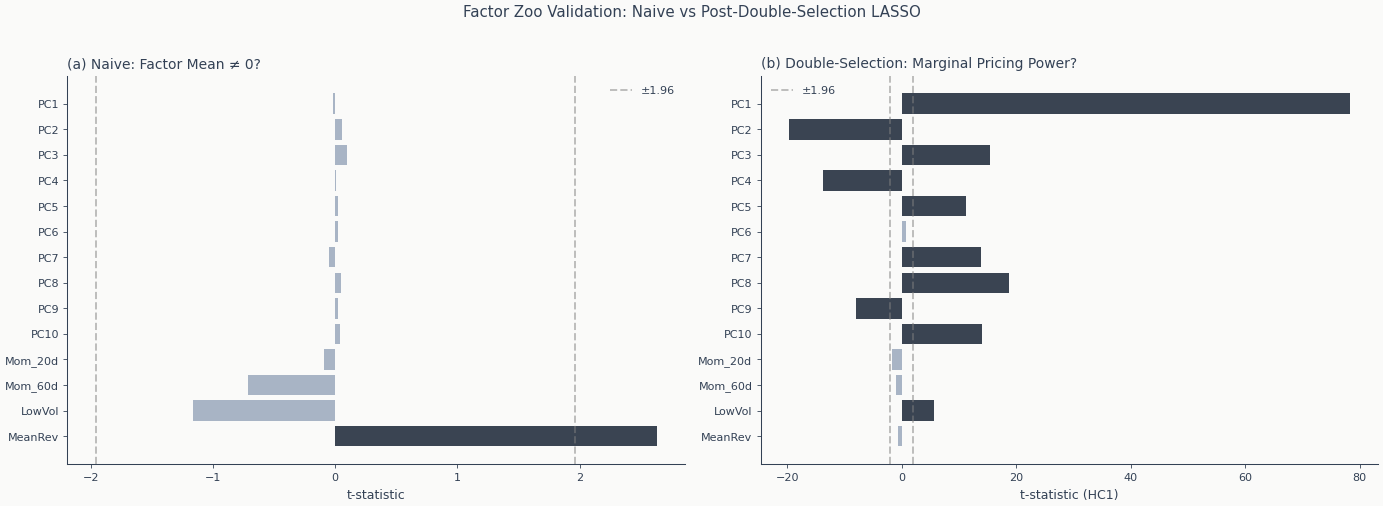

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): Naive t-statistics
naive_tstats = []
for i in range(n_zoo):
    series = zoo_trimmed[:, i]
    t_stat, _ = ttest_1samp(series, 0)
    naive_tstats.append(t_stat)

ax = axes[0]
colors_naive = [COLORS["blue"] if abs(t) > 1.96 else "#94a3b8" for t in naive_tstats]
ax.barh(range(n_zoo), naive_tstats, color=colors_naive, alpha=0.8)
ax.axvline(-1.96, color="gray", linestyle="--", alpha=0.5)
ax.axvline(1.96, color="gray", linestyle="--", alpha=0.5, label="±1.96")
ax.set_yticks(range(n_zoo))
ax.set_yticklabels(zoo_names, fontsize=8)
ax.set_xlabel("t-statistic")
ax.set_title("(a) Naive: Factor Mean ≠ 0?")
ax.legend(fontsize=8)
ax.invert_yaxis()

# Panel (b): Double-selection t-statistics
ds_tstats = [r["t_stat"] for r in results]
colors_ds = [COLORS["blue"] if r["significant"] else "#94a3b8" for r in results]
ax = axes[1]
ax.barh(range(n_zoo), ds_tstats, color=colors_ds, alpha=0.8)
ax.axvline(-1.96, color="gray", linestyle="--", alpha=0.5)
ax.axvline(1.96, color="gray", linestyle="--", alpha=0.5, label="±1.96")
ax.set_yticks(range(n_zoo))
ax.set_yticklabels(zoo_names, fontsize=8)
ax.set_xlabel("t-statistic (HC1)")
ax.set_title("(b) Double-Selection: Marginal Pricing Power?")
ax.legend(fontsize=8)
ax.invert_yaxis()

fig.suptitle("Factor Zoo Validation: Naive vs Post-Double-Selection LASSO", y=1.02)
fig.tight_layout()
fig.show()

**Finding**: Panels (a) and (b) test different null hypotheses. Panel (a)
asks whether each factor's *time-series mean* is non-zero — a question
about expected return. Panel (b) asks whether each factor has *marginal
pricing power for `HOLDOUT_SYMBOL`* after orthogonalizing against the rest
of the zoo. Most PCA factors retain large t-stats in panel (b): the
held-out broad-market ETF is well approximated by a low-rank projection
onto the 99-ETF panel, so every principal component carries a distinct
(and statistically detectable) loading. The managed-portfolio candidates
(`Mom_20d`, `Mom_60d`, `MeanRev`) instead collapse to insignificance once
orthogonalized against the PCA basis — they do not add information beyond
what the unsupervised decomposition already captures. `LowVol` is the lone
managed-portfolio survivor, picking up a defensive-tilt residual that is
not spanned by the leading PCs.

## 7. Which Controls Were Selected?

The LASSO selection pattern reveals the structure of the factor zoo. If the
pricing LASSO and correlation LASSO select similar controls, the candidate
is entangled with the zoo. If they select different controls, the candidate
captures a distinct dimension.

In [12]:
for r in results:
    if r["n_union"] > 0:
        print(
            f"{r['factor']:>10}: {r['n_union']} controls selected → {', '.join(r['selected_names'][:5])}"
        )

       PC1: 13 controls selected → PC2, PC3, PC4, PC5, PC6
       PC2: 13 controls selected → PC1, PC3, PC4, PC5, PC6
       PC3: 13 controls selected → PC1, PC2, PC4, PC5, PC6
       PC4: 8 controls selected → PC1, PC2, PC3, PC5, PC7
       PC5: 8 controls selected → PC1, PC2, PC3, PC4, PC7
       PC6: 13 controls selected → PC1, PC2, PC3, PC4, PC5
       PC7: 13 controls selected → PC1, PC2, PC3, PC4, PC5
       PC8: 8 controls selected → PC1, PC2, PC3, PC4, PC5
       PC9: 13 controls selected → PC1, PC2, PC3, PC4, PC5
      PC10: 8 controls selected → PC1, PC2, PC3, PC4, PC5
   Mom_20d: 12 controls selected → PC1, PC2, PC3, PC4, PC5
   Mom_60d: 11 controls selected → PC1, PC2, PC3, PC4, PC5
    LowVol: 10 controls selected → PC1, PC2, PC3, PC4, PC5
   MeanRev: 11 controls selected → PC1, PC2, PC3, PC4, PC5


## Key Takeaways

1. **Naive factor testing overstates significance** because it ignores
   correlations with existing factors (omitted variable bias)
2. **Post-double-selection LASSO** (Feng, Giglio, and Xiu 2020) is a
   special case of the DML framework (§15.3): two LASSO models handle the
   outcome and treatment equations, then OLS tests the candidate on the
   union of selected controls
3. **The procedure is conservative**: it controls for the hardest confounders
   (those that correlate with both returns AND the candidate)
4. **Implementation requires only sklearn + statsmodels**: `LassoCV` for
   selection, `LinearRegression` for the final test, HC1 standard errors
   for robust inference
5. **The results are data-dependent**: with a held-out broad-market ETF
   as the outcome and PCA factors built from the rest of the universe,
   most PCs retain pricing power because the held-out asset is nearly
   spanned by the panel. Among the managed-portfolio candidates only the
   low-volatility tilt survives — momentum and mean-reversion variants
   lose significance once the procedure orthogonalizes them against the
   principal-component basis

**Connection to §15.3**: The double-selection procedure is the BCH (2014)
precursor to DML. Where DML uses cross-fitting for general ML nuisance
models, post-double-selection uses LASSO's built-in sparsity for variable
selection. Both solve the same problem: removing confounding bias from
high-dimensional settings.

**Back to Chapter 14**: This validates the "Taming the Factor Zoo" discussion
in §14.5. Any new latent factor discovered via IPCA, CAE, or SDF should be
tested with this procedure before being deployed in production.